In [1]:
from itertools import combinations
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

from scipy.spatial.distance import squareform
from scipy.stats import spearmanr, pearsonr
from scipy.spatial.distance import pdist

from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances

# Habitat cluster MDS

In [2]:
def do_MDS(distance_matrix):
    #Set MDS
    mds = MDS(n_components=40, dissimilarity='precomputed', max_iter=500000, n_init=500, eps=1e-08, random_state=1, normalized_stress='auto')
        
    coordinates = mds.fit_transform(distance_matrix.values)

    df = pd.DataFrame(coordinates)
    df.index = distance_matrix.index

    return df

def compare_distances(d_arr_1, d_arr_2, visualize=True):
    pearson_stat, pearson_p = pearsonr(d_arr_1, d_arr_2)
    spearman_stat, spearman_p = spearmanr(d_arr_1, d_arr_2)
    print ("Pearson's r = "+str(pearson_stat)+", p = "+str(pearson_p))
    print ("Spearmann's rho = "+str(spearman_stat)+", p = "+str(spearman_p))

    if visualize:
        fig, ax = plt.subplots(figsize=(5,5))
        ax.scatter(d_arr_1, d_arr_2)
        plt.show()
        plt.close()


def find_best_axes(habitat_coordinates, d_arr, dim=3):
    max_r = 0
    for axes in combinations(habitat_coordinates.columns, dim):
        distances = pdist(habitat_coordinates[list(axes)])
        r, p = pearsonr(d_arr, distances)
        if r > max_r:
            max_r = r
            max_axes = list(axes)
            max_distance_arr = distances
    return (max_axes, max_r, max_distance_arr)

In [3]:
# Load ecological distance between the habitat clusters
ecolocal_distance_dmatrix = pd.read_csv('./data/ecological_distance_between_habitat_clusters.tsv', sep='\t', index_col=0, header=0)

In [4]:
# Perform Multidimentional scaling
habitat_cluster_coordinates = do_MDS(ecolocal_distance_dmatrix)

Pearson's r = 0.9820969437026243, p = 0.0
Spearmann's rho = 0.9780806548131938, p = 0.0


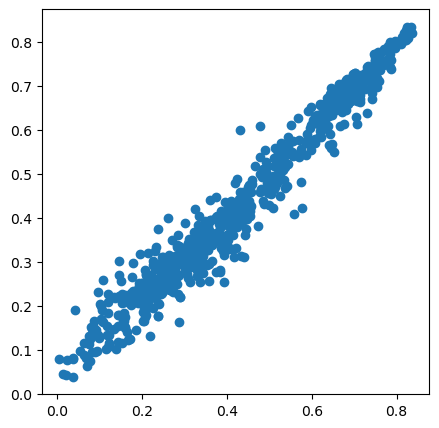

In [5]:
# Check whether the MDS distance correlates to the original ecological distance
# Extended Data Fig. 7B
compare_distances(squareform(ecolocal_distance_dmatrix.values), pdist(habitat_cluster_coordinates))

In [6]:
# optional: this is to find the three axes which correlates the best with the original distance matrix
#best_three_axes, pearson, three_axes_d = find_best_axes(habitat_cluster_coordinates, squareform(ecolocal_distance_dmatrix.values), dim=3)
#best_three_axes = [17, 28, 38]

# Calculate generalism score

In [7]:
def get_generalism_score(target_taxon_df, habitat_cluster_coordinates, visualize=True):
    if len(target_taxon_df) == 1:
        # If a species is found in only one cluster, it is assigned a score of 0 according to the definition of the generalism score.
        # However, if you calculate it using the following method, a very small nonzero value may result due to Python's floating point calculation error.
        # To prevent this, we separated this case.
        generalism_score = 0
        if visualize:
            print('Defined in only one habitat cluster, skip visualization')
        return generalism_score
         
    else:
        # calculate weights by mean abundance
        target_taxon_df['weight'] = target_taxon_df['mean_abundance'] / max(target_taxon_df['mean_abundance'])
    
        defined_habitat_cluster_coorinates = habitat_cluster_coordinates.loc[target_taxon_df['cluster']]
    
        # calculate weighted centroid cooridates
        w_centroid = defined_habitat_cluster_coorinates.T * np.array(target_taxon_df['weight'])
        w_centroid = w_centroid.sum(axis=1) / target_taxon_df['weight'].sum()
    
        # distance between weighted centroid and defined habitat clusters
        d = pairwise_distances(defined_habitat_cluster_coorinates, np.array([w_centroid]), metric='euclidean').flatten()
    
        generalism_score = (d**2 * target_taxon_df['weight']).sum()

        if visualize:
            visualize_generalism(w_centroid, target_taxon_df, habitat_cluster_coordinates)
        
        return generalism_score
    

def visualize_generalism(w_centroid, target_taxon_df, habitat_cluster_coordinates, axes=[17, 28, 38]):
    # Color code used in the paper
    if (len(axes) != 2) and (len(axes) != 3):
        raise ValueError("Unsupported dimension: only 2D and 3D axes are supported.")
    
    cluster_colormap = {'HTS': '#733C93', 'OLL': '#004C87', 'OIL': '#004677', 'OHL': '#004067', 'POL': '#50B4C4', 'EST': '#0073BB', 'FRW': '#A3B8E0', 'TEH': '#604242',
                         'TER': '#AE9482', 'TEG': '#9C7862', 'ADC': '#901D22', 'HOR': '#BF1A20', 'HUV': '#ff60d4', 'HSS': '#c9c28b', 'BLD': '#5D5E5E', 'HET': '#A0A0A0',
                         'WT1': '#322D31', 'ANI': '#C35E22', 'MOG': '#D58A81', 'RMG': '#D58A89', 'CKG': '#D86F7C', 'APG': '#EFA080', 'HG1': '#EF5905', 'MKG': '#EC9706',
                         'PG1': '#E78D69', 'PG2': '#EA8F6B', 'WT2': '#302028', 'HG2': '#E84C05', 'HG3': '#F64C05', 'HG4': '#FF4C05', 'HG5': '#FA4C05', 'HG6': '#EF5305',
                         'HG7': '#E14C05', 'NBG': '#F87030', 'IFG': '#F07030', 'CDG': '#F5CEBA', 'BG1': '#DAAA9A', 'BG2': '#DCA79A', 'BG3': '#D8A598', 'HRG': '#DCAA9D'}

    coordinates_target_axes = habitat_cluster_coordinates[axes].copy()
    coordinates_target_axes['cluster_color'] = coordinates_target_axes.index.map(cluster_colormap)
    coordinates_target_axes['edge_color'] = coordinates_target_axes.index.map(lambda x: 'red' if x in target_taxon_df['cluster'].values else 'none')
    coordinates_target_axes['alpha'] = coordinates_target_axes.index.map(lambda x: 1 if x in target_taxon_df['cluster'].values else 0.7)
    coordinates_target_axes['size'] = coordinates_target_axes.index.map(lambda x: 100 if x in target_taxon_df['cluster'].values else 70)
    coordinates_target_axes = coordinates_target_axes.merge(target_taxon_df[['cluster', 'weight']], left_index=True, right_on='cluster', how='outer').fillna(0)

    rgba_colors = [
        mcolors.to_rgba(color, alpha=a)
        for color, a in zip(coordinates_target_axes['cluster_color'], coordinates_target_axes['alpha'])
    ]

    #Scaling for visualization
    #min width to 0.1, max width to 7.1
    coordinates_target_axes['weight'] = (coordinates_target_axes['weight'] / max(coordinates_target_axes['weight'])) * 7 + 0.1
    
    
    fig = plt.figure(figsize=(6, 6))
    if len(axes) == 2:
        # 2D plotting
        ax = fig.add_subplot(111)

        # Draw lines between weighted centroid and defined clusters
        for cluster, row in coordinates_target_axes[coordinates_target_axes['edge_color'] == 'red'].iterrows():
            ax.plot([w_centroid[axes[0]], row[axes[0]]],
                    [w_centroid[axes[1]], row[axes[1]]],
                    color='black', zorder=1, linewidth=row['weight'])

        ax.scatter(coordinates_target_axes[axes[0]], 
                   coordinates_target_axes[axes[1]], 
                   c=rgba_colors, marker='o', 
                   edgecolors=coordinates_target_axes['edge_color'], s=coordinates_target_axes['size'], zorder=2)
        
        ax.scatter(w_centroid[axes[0]], 
                   w_centroid[axes[1]], 
                   c='red', marker='*', s=200, zorder=2, edgecolors='white')

        ax.set_xlabel('MDS '+str(axes[0]))
        ax.set_ylabel('MDS '+str(axes[1]))
        
    else:
        ax = fig.add_subplot(111, projection='3d')
        # Draw lines between weighted centroid and defined clusters
        for cluster, row in coordinates_target_axes[coordinates_target_axes['edge_color'] == 'red'].iterrows():
            ax.plot([w_centroid[axes[0]], row[axes[0]]],
                    [w_centroid[axes[1]], row[axes[1]]],
                    [w_centroid[axes[2]], row[axes[2]]],
                    linewidth=row['weight'], color='black')


        ax.scatter(coordinates_target_axes[axes[0]], 
                   coordinates_target_axes[axes[1]], 
                   coordinates_target_axes[axes[2]],
                   c=rgba_colors,
                   marker='o', 
                   edgecolors=coordinates_target_axes['edge_color'],
                   s=coordinates_target_axes['size'],
                   depthshade=False,
                   zorder=1)
        
        ax.scatter(w_centroid[axes[0]], 
                   w_centroid[axes[1]], 
                   w_centroid[axes[2]], 
                   c='red', marker='*', s=200, edgecolors='white')

        # Draw lines from the centroid to target clusters
        ax.set_xlabel('MDS '+str(axes[0]))
        ax.set_ylabel('MDS '+str(axes[1]))
        ax.set_zlabel('MDS '+str(axes[2]))

    plt.show()

In [10]:
#Please use GTDB r207 taxonomy
target_taxon = 'd__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rhizobiales;f__Xanthobacteraceae;g__Afipia;s__Afipia sp000497575'
#target_taxon = 'd__Bacteria;p__Actinobacteriota;c__Actinomycetia;o__Propionibacteriales;f__Propionibacteriaceae;g__Cutibacterium;s__Cutibacterium acnes'
#target_taxon = 'd__Bacteria;p__Actinobacteriota;c__Actinomycetia;o__Actinomycetales;f__Bifidobacteriaceae;g__Bifidobacterium;s__Bifidobacterium longum'

prevalence_cutoff = 0.01

taxon_prevalence_abundance_df = pd.read_csv("./data/taxon_prevalence_mean-abundance.tsv", sep="\t")
taxon_prevalence_abundance_df = taxon_prevalence_abundance_df[taxon_prevalence_abundance_df['prevalence'] > prevalence_cutoff]

target_taxon_df = taxon_prevalence_abundance_df[
    taxon_prevalence_abundance_df['taxon'] == target_taxon].copy()

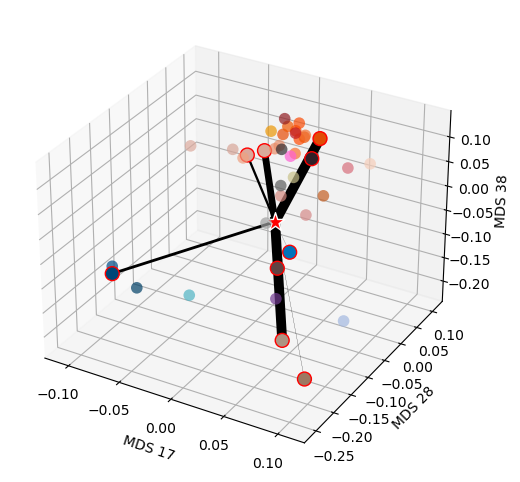

Generalism score: 0.5121548301686372


In [11]:
generalism_score = get_generalism_score(target_taxon_df, habitat_cluster_coordinates, visualize=True)
print ('Generalism score: '+str(generalism_score))